# From wavefunctions to the hydrogen atom

- **See:** particle in a box → harmonic oscillator → hydrogen atom.
- **Compute:** the hydrogen ground state; compare with the exact solution.
- **Run:** NumPy, SciPy, Matplotlib; **Restart Kernel → Run All**.
- **Try:** change one marked value; rerun that cell and the cells below it.

### Setup

**Learn**
- NumPy stores sampled functions; Matplotlib draws them.
- `eigh_tridiagonal` will find energies and wavefunctions.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 12,
    "figure.dpi": 130, "axes.linewidth": 0.9, "lines.linewidth": 1.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.top": False, "ytick.right": False,
})
BLUE, ORANGE = "#245B87", "#B64D20"

## 1. What does the Schrödinger equation give us?

$$\underbrace{-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2}}_{\text{kinetic term}}
+\underbrace{V(x)\psi(x)}_{\text{potential term}}=E\psi(x).$$

- **Given:** the potential and boundary conditions.
- **Find:** allowed energies and their wavefunctions.
- **Meaning:** wavefunction amplitude can be negative; probability cannot.

$$P(a\leq x\leq b)=\int_a^b|\psi(x)|^2dx,
\qquad \int_{-\infty}^{\infty}|\psi(x)|^2dx=1.$$

- We study stationary states: their probability density does not change in time.

## 2. Particle in a box: exact solutions

- Zero potential inside; infinite walls at both ends.
- The wavefunction vanishes at each wall.

$$V(x)=\begin{cases}0,&0<x<L,\\\infty,&\text{otherwise},\end{cases}
\qquad \psi(0)=\psi(L)=0.$$

$$\psi_n(x)=\sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x}{L}\right),
\qquad E_n=\frac{n^2\pi^2\hbar^2}{2mL^2},\quad n=1,2,3,\ldots$$

- Use the scaled position and amplitude below; no tiny SI numbers are needed.

$$q=\frac{x}{L},\qquad \phi_n(q)=\sqrt{L}\,\psi_n(Lq)
=\sqrt2\sin(n\pi q),\qquad \frac{E_n}{E_1}=n^2.$$

### Evaluate three exact states

**Learn**
- `q_box` samples the interval; each row of `box_waves` is one state.
- Squaring the amplitude gives probability density in the scaled coordinate.

In [2]:
q_box = np.linspace(0, 1, 601)
box_n = np.array([1, 2, 3])
box_waves = np.array([np.sqrt(2) * np.sin(n * np.pi * q_box)
                      for n in box_n])
box_density = np.abs(box_waves)**2
box_energy = box_n**2  # E / E_1
print("n:", box_n)
print("E / E_1:", box_energy)
print("Probability integrals:", np.trapezoid(box_density, q_box, axis=1))

n: [1 2 3]
E / E_1: [1 4 9]
Probability integrals: [1. 1. 1.]


### Read amplitude and probability side by side

**Learn**
- Left: blue and orange mark positive and negative amplitude.
- Right: both signs give positive probability density; all rows share scales.
- **Check:** count the internal nodes; ignore the two walls.

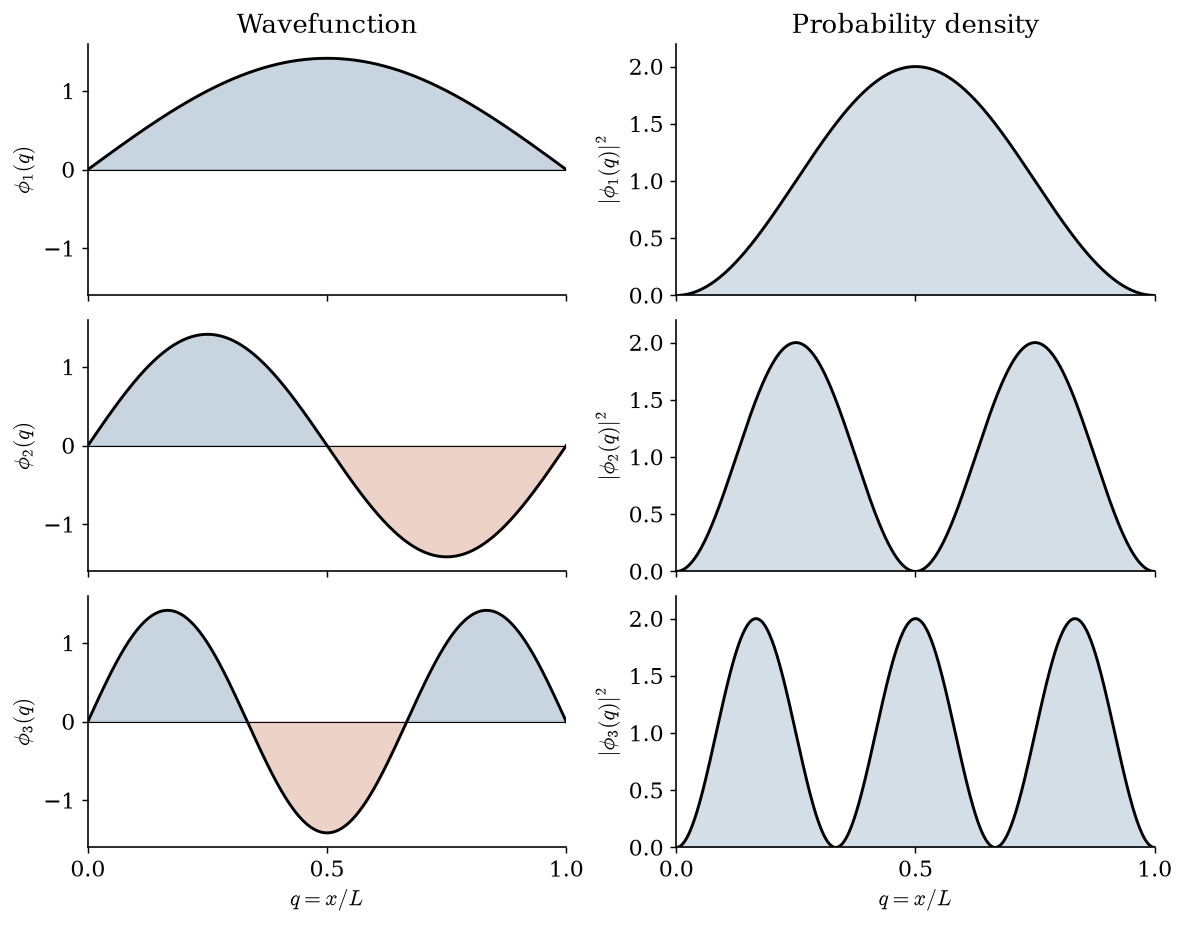

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(9, 7), sharex=True,
                         sharey="col", layout="constrained")
for j, n in enumerate(box_n):
    left, right = axes[j]
    left.plot(q_box, box_waves[j], color="black")
    left.fill_between(q_box, box_waves[j], where=box_waves[j] >= 0,
                      color=BLUE, alpha=0.25)
    left.fill_between(q_box, box_waves[j], where=box_waves[j] < 0,
                      color=ORANGE, alpha=0.25)
    right.plot(q_box, box_density[j], color="black")
    right.fill_between(q_box, box_density[j], color=BLUE, alpha=0.2)
    left.set(ylabel=rf"$\phi_{n}(q)$", ylim=(-1.6, 1.6))
    right.set(ylabel=rf"$|\phi_{n}(q)|^2$", ylim=(0, 2.2))
    for ax in (left, right):
        ax.axhline(0, color="black", lw=0.6)
        ax.set(xlim=(0, 1), xticks=[0, 0.5, 1])
axes[0, 0].set_title("Wavefunction")
axes[0, 1].set_title("Probability density")
for ax in axes[-1]:
    ax.set_xlabel(r"$q=x/L$")
plt.show()

### Probability is an area

**Learn**
- `n_box` selects a state; the mask selects a position interval.
- `trapezoid` adds the area under the probability curve.
- **Try:** change `n_box` from 1 to 2; compare the central probability.

Probability in the selected interval: 0.8183


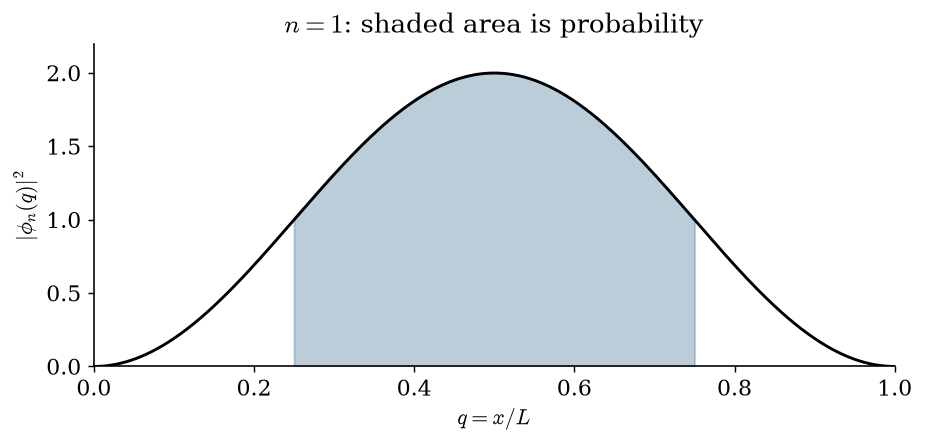

In [4]:
n_box = 1  # Try 1, 2, 3.
q_left, q_right = 0.25, 0.75
selected = (q_box >= q_left) & (q_box <= q_right)
p_box = box_density[n_box - 1]
probability_box = np.trapezoid(p_box[selected], q_box[selected])
print(f"Probability in the selected interval: {probability_box:.4f}")
fig, ax = plt.subplots(figsize=(7, 3.3), layout="constrained")
ax.plot(q_box, p_box, color="black")
ax.fill_between(q_box, p_box, where=selected, color=BLUE, alpha=0.3)
ax.set(xlabel=r"$q=x/L$", ylabel=r"$|\phi_n(q)|^2$", xlim=(0, 1),
       ylim=(0, 2.2), title=rf"$n={n_box}$: shaded area is probability")
plt.show()

## 3. Harmonic oscillator: exact solutions

$$V(x)=\frac12m\omega^2x^2,\qquad E_n=\left(n+\frac12\right)\hbar\omega,
\quad n=0,1,2,\ldots$$

- A smooth confining potential replaces the hard walls.
- Use the oscillator length; the energy spacing is constant.

$$b=\sqrt{\frac{\hbar}{m\omega}},\qquad q=\frac{x}{b},\qquad
\phi_n(q)=\sqrt b\,\psi_n(bq),\qquad \epsilon_n=\frac{E_n}{\hbar\omega}=n+\frac12.$$

$$\phi_0=\pi^{-1/4}e^{-q^2/2},\qquad
\phi_1=\sqrt2\,q\phi_0,\qquad
\phi_2=\frac{2q^2-1}{\sqrt2}\phi_0.$$

### Build the first three oscillator states

**Learn**
- A Gaussian gives the ground state; polynomial factors create nodes.
- Rows 0, 1, 2 correspond to the ground state and two excited states.

In [5]:
q_ho = np.linspace(-5, 5, 1001)
gaussian = np.pi**(-0.25) * np.exp(-q_ho**2 / 2)
ho_waves = np.array([gaussian, np.sqrt(2) * q_ho * gaussian,
                     (2 * q_ho**2 - 1) * gaussian / np.sqrt(2)])
ho_density = np.abs(ho_waves)**2
ho_energy = np.arange(3) + 0.5
print("E / (hbar omega):", ho_energy)
print("Probability integrals:", np.trapezoid(ho_density, q_ho, axis=1))

E / (hbar omega): [0.5 1.5 2.5]
Probability integrals: [1. 1. 1.]


### Compare with the box

**Learn**
- Use the same amplitude/probability layout and shared scales.
- Oscillator wavefunctions decay smoothly; there are no hard walls.
- **Check:** compare node counts for the first three states of each system.

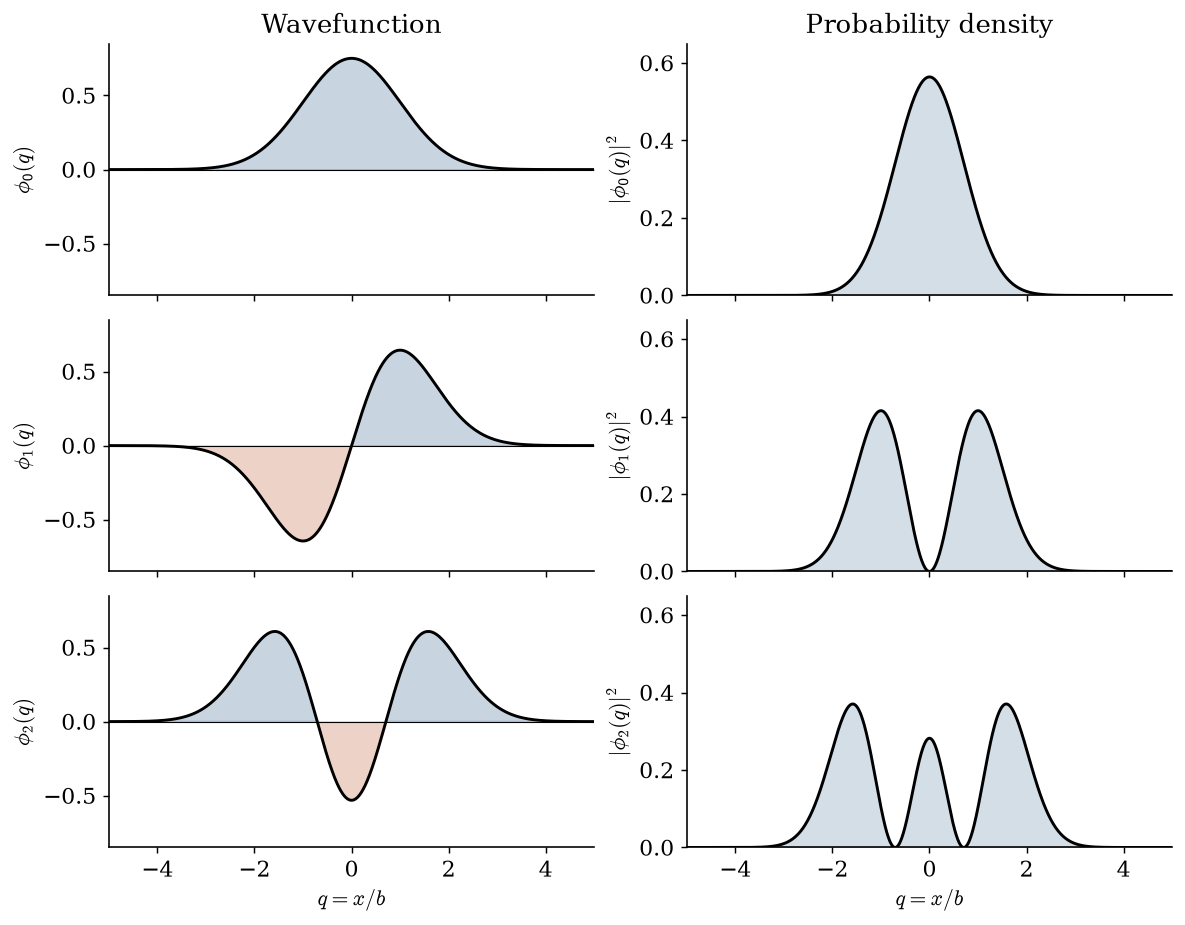

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(9, 7), sharex=True,
                         sharey="col", layout="constrained")
for n in range(3):
    left, right = axes[n]
    left.plot(q_ho, ho_waves[n], color="black")
    left.fill_between(q_ho, ho_waves[n], where=ho_waves[n] >= 0,
                      color=BLUE, alpha=0.25)
    left.fill_between(q_ho, ho_waves[n], where=ho_waves[n] < 0,
                      color=ORANGE, alpha=0.25)
    right.plot(q_ho, ho_density[n], color="black")
    right.fill_between(q_ho, ho_density[n], color=BLUE, alpha=0.2)
    left.set(ylabel=rf"$\phi_{n}(q)$", ylim=(-0.85, 0.85))
    right.set(ylabel=rf"$|\phi_{n}(q)|^2$", ylim=(0, 0.65))
    for ax in (left, right):
        ax.axhline(0, color="black", lw=0.6)
        ax.set(xlim=(-5, 5), xticks=[-4, -2, 0, 2, 4])
axes[0, 0].set_title("Wavefunction")
axes[0, 1].set_title("Probability density")
for ax in axes[-1]:
    ax.set_xlabel(r"$q=x/b$")
plt.show()

### A quantum particle extends beyond the turning points

**Learn**
- Dashed lines mark the classical turning points: potential equals energy.
- The shaded tails lie outside the classical allowed region.
- **Try:** change `n_ho`; the turning points and the density both change.

$$q_{\mathrm{turn}}=\pm\sqrt{2\epsilon_n}.$$

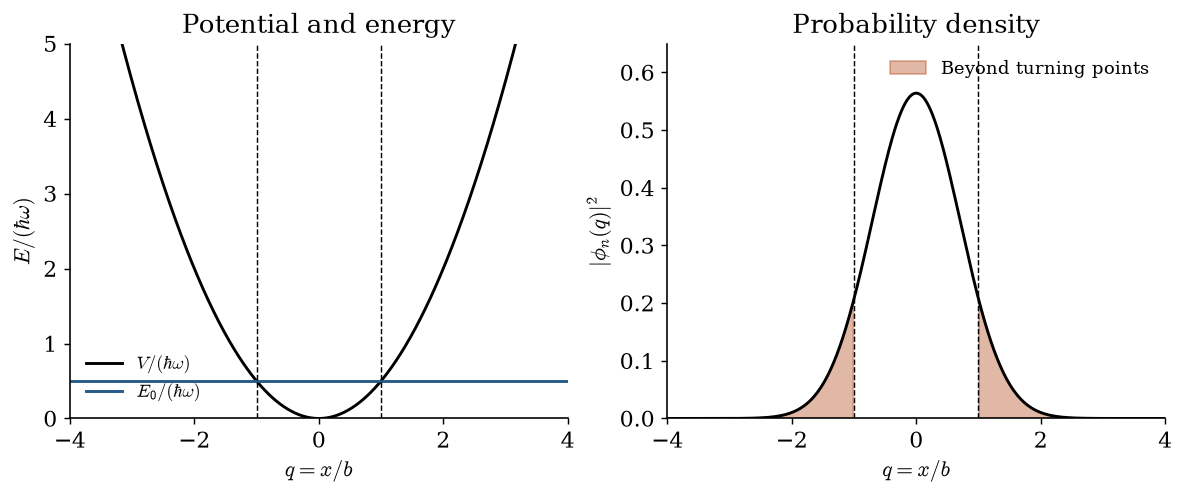

In [7]:
n_ho = 0  # Try 0, 1, 2.
turning = np.sqrt(2 * ho_energy[n_ho])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), layout="constrained")
axes[0].plot(q_ho, q_ho**2 / 2, color="black", label=r"$V/(\hbar\omega)$")
axes[0].axhline(ho_energy[n_ho], color=BLUE, label=rf"$E_{n_ho}/(\hbar\omega)$")
axes[1].plot(q_ho, ho_density[n_ho], color="black")
axes[1].fill_between(q_ho, ho_density[n_ho], where=np.abs(q_ho) > turning,
                     color=ORANGE, alpha=0.4, label="Beyond turning points")
for ax in axes:
    ax.axvline(-turning, color="black", ls="--", lw=0.8)
    ax.axvline(turning, color="black", ls="--", lw=0.8)
    ax.set(xlabel=r"$q=x/b$", xlim=(-4, 4), xticks=[-4, -2, 0, 2, 4])
    ax.legend(frameon=False, fontsize=10)
axes[0].set(ylabel=r"$E/(\hbar\omega)$", ylim=(0, 5), title="Potential and energy")
axes[1].set(ylabel=r"$|\phi_n(q)|^2$", ylim=(0, 0.65), title="Probability density")
plt.show()

### Two different energy ladders

**Learn**
- Box levels spread apart; oscillator levels are equally spaced.
- Each panel divides energy by its own ground-state energy.
- **Check:** doubling the box width divides every physical energy by four.

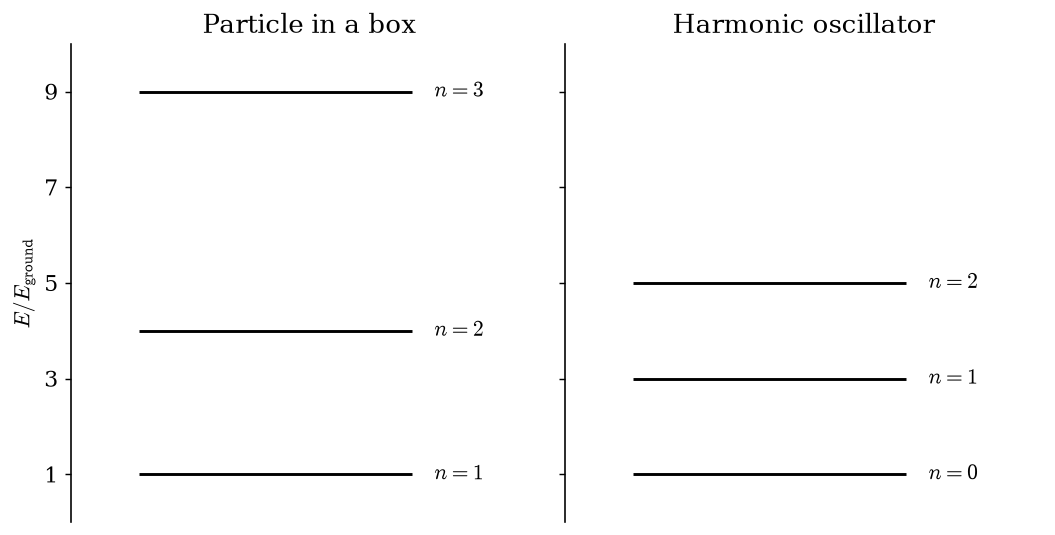

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout="constrained")
level_sets = [box_energy, ho_energy / ho_energy[0]]
labels = [[1, 2, 3], [0, 1, 2]]
for ax, levels, numbers, title in zip(axes, level_sets, labels,
                                      ["Particle in a box", "Harmonic oscillator"]):
    for energy, n in zip(levels, numbers):
        ax.hlines(energy, 0.15, 0.75, color="black")
        ax.text(0.8, energy, rf"$n={n}$", va="center")
    ax.set(xlim=(0, 1.05), ylim=(0, 10), xticks=[], yticks=[1, 3, 5, 7, 9], title=title)
    ax.spines["bottom"].set_visible(False)
axes[0].set_ylabel(r"$E/E_{\mathrm{ground}}$")
plt.show()

## 4. Hydrogen atom: exact solutions

- Fixed proton; one nonrelativistic electron.
- Atomic units: length in Bohr radii, energy in Hartree.
- From here, coordinates and wavefunctions use their atomic-unit numerical values.

$$a_0=\frac{4\pi\varepsilon_0\hbar^2}{m_e e^2},\qquad
E_{\mathrm{h}}=\frac{\hbar^2}{m_e a_0^2}.$$

$$\left[-\frac12\nabla^2-\frac1r\right]\psi=E\psi,
\qquad E_n=-\frac{1}{2n^2},\quad n=1,2,\ldots$$

$$\psi_{1s}(r)=\frac{e^{-r}}{\sqrt\pi},\qquad E_{1s}=-\frac12.$$

- Zero energy: an electron at rest infinitely far away. Bound states have negative energy.
- The ground state depends only on distance from the nucleus.
- An orbital is a spatial wavefunction, not an electron trajectory.

### Sample a plane through the nucleus

**Learn**
- `meshgrid` gives the horizontal and vertical coordinate at every pixel.
- On the plane `y = 0`, distance is the square root of the two squared coordinates.

$$r=\sqrt{x^2+z^2}\quad(y=0),\qquad \rho(x,0,z)=|\psi_{1s}(r)|^2.$$

In [7]:
axis_h = np.linspace(-3, 3, 301)
X, Z = np.meshgrid(axis_h, axis_h)
r_plane = np.sqrt(X**2 + Z**2)
psi_plane = np.exp(-r_plane) / np.sqrt(np.pi)
rho_plane = np.abs(psi_plane)**2
print("Density array shape:", rho_plane.shape)

Density array shape: (301, 301)


### See the ground-state density

**Learn**
- Color shows probability per unit volume, sampled on one plane.
- This slice is not a two-dimensional probability distribution.
- **Check:** the density is largest at the nucleus.

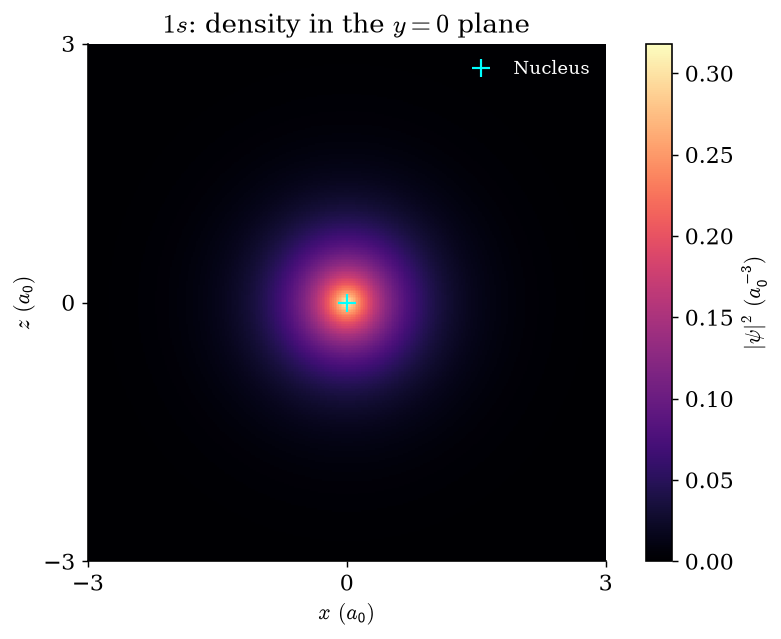

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.8), layout="constrained")
im = ax.imshow(rho_plane, extent=[-3, 3, -3, 3], origin="lower",
               cmap="magma", vmin=0, vmax=1 / np.pi, interpolation="nearest")
ax.plot(0, 0, "+", color="cyan", ms=10, mew=1.2, label="Nucleus")
ax.set(xlabel=r"$x\ (a_0)$", ylabel=r"$z\ (a_0)$",
       xticks=[-3, 0, 3], yticks=[-3, 0, 3], title=r"$1s$: density in the $y=0$ plane")
ax.legend(frameon=False, labelcolor="white", loc="upper right", fontsize=10)
fig.colorbar(im, ax=ax, label=r"$|\psi|^2\ (a_0^{-3})$")
plt.show()

### Density at a point versus probability in a shell

**Learn**
- A shell at larger radius contains more volume.
- Left: density per volume. Right: probability density per radius.
- **Check:** only the right-hand curve has unit area.

$$P(r)\,dr=4\pi r^2|\psi_{1s}(r)|^2dr,\qquad P(r)=4r^2e^{-2r}.$$

Probability inside 8 bohr: 0.999984


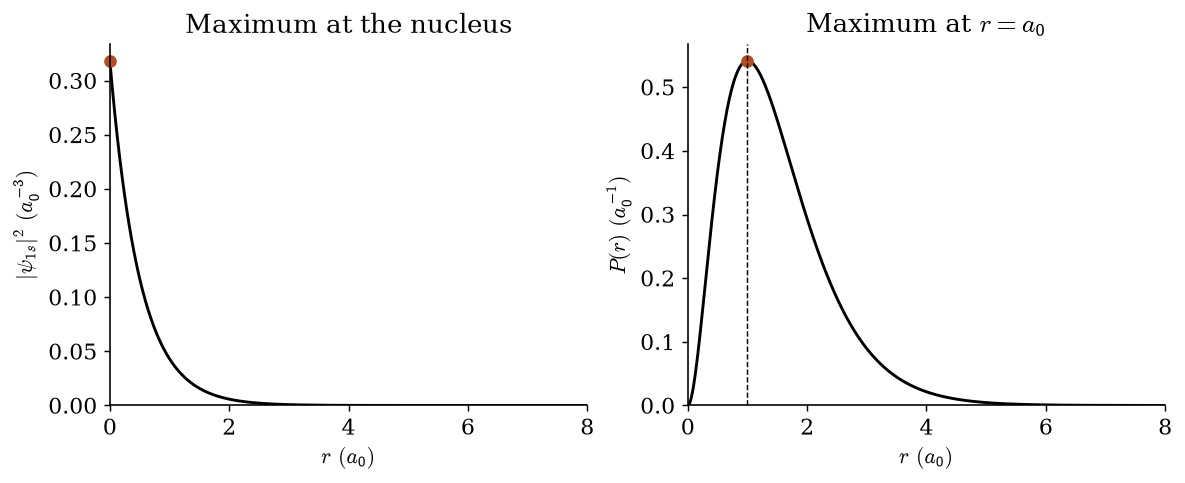

In [9]:
r_exact = np.linspace(0, 8, 801)
rho_exact = np.exp(-2 * r_exact) / np.pi
P_exact = 4 * np.pi * r_exact**2 * rho_exact
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, layout="constrained")
axes[0].plot(r_exact, rho_exact, color="black")
axes[1].plot(r_exact, P_exact, color="black")
axes[0].plot(0, 1 / np.pi, "o", color=ORANGE, clip_on=False)
axes[1].plot(1, 4 * np.exp(-2), "o", color=ORANGE)
axes[1].axvline(1, color="black", ls="--", lw=0.8)
axes[0].set(ylabel=r"$|\psi_{1s}|^2\ (a_0^{-3})$", title="Maximum at the nucleus")
axes[1].set(ylabel=r"$P(r)\ (a_0^{-1})$", title=r"Maximum at $r=a_0$")
for ax in axes:
    ax.set(xlabel=r"$r\ (a_0)$", xlim=(0, 8), ylim=(0, None), xticks=[0, 2, 4, 6, 8])
print(f"Probability inside 8 bohr: {np.trapezoid(P_exact, r_exact):.6f}")
plt.show()

### Optional: nodes in two excited orbitals

**Learn**
- These are exact real wavefunctions, not numerical solutions.
- Color gives the sign and relative amplitude; each panel uses its own peak.
- Dashed curves mark zero amplitude: a spherical node in the second state; a nodal plane in the third.

$$\psi_{2s}=\frac{(2-r)e^{-r/2}}{4\sqrt{2\pi}},\qquad
\psi_{2p_z}=\frac{z\,e^{-r/2}}{4\sqrt{2\pi}}.$$

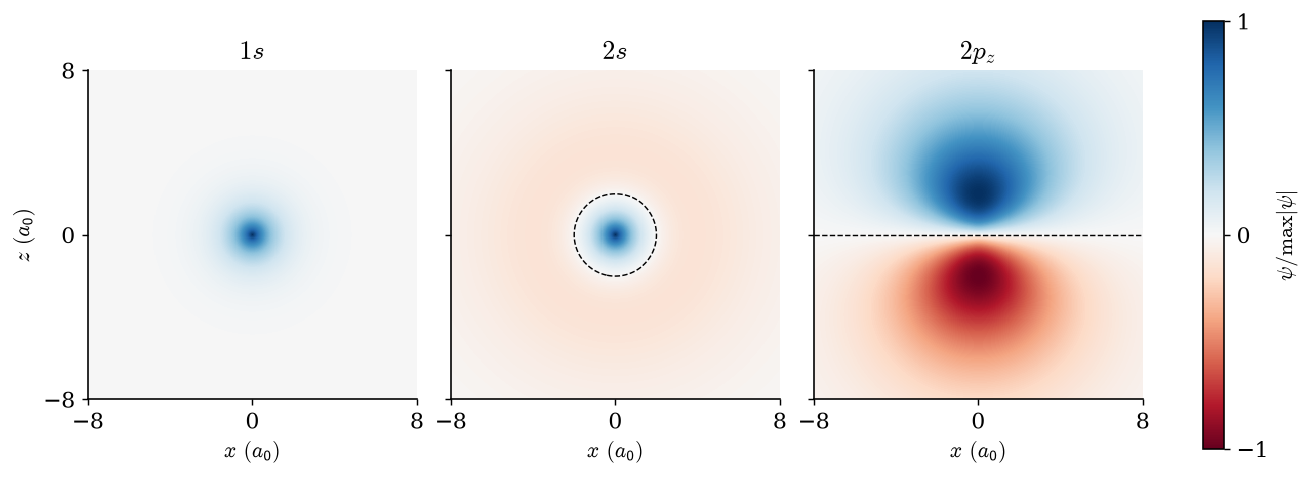

In [10]:
axis_orbital = np.linspace(-8, 8, 321)
XO, ZO = np.meshgrid(axis_orbital, axis_orbital)
RO = np.sqrt(XO**2 + ZO**2)
orbital_waves = [np.exp(-RO) / np.sqrt(np.pi),
                 (2 - RO) * np.exp(-RO / 2) / (4 * np.sqrt(2 * np.pi)),
                 ZO * np.exp(-RO / 2) / (4 * np.sqrt(2 * np.pi))]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharex=True, sharey=True,
                         layout="constrained")
for ax, wave, name in zip(axes, orbital_waves, ["1s", "2s", "2p_z"]):
    im = ax.imshow(wave / np.max(np.abs(wave)), origin="lower", extent=[-8, 8, -8, 8],
                   cmap="RdBu", vmin=-1, vmax=1, interpolation="nearest")
    ax.set(title=rf"${name}$", xlabel=r"$x\ (a_0)$", xticks=[-8, 0, 8], yticks=[-8, 0, 8])
    if name != "1s":
        ax.contour(XO, ZO, wave, levels=[0], colors="black", linestyles="--", linewidths=0.8)
axes[0].set_ylabel(r"$z\ (a_0)$")
fig.colorbar(im, ax=axes, ticks=[-1, 0, 1], label=r"$\psi/\max|\psi|$")
plt.show()

## 5. Hydrogen: numerical solution

- Start from the three-dimensional Schrödinger PDE.
- Spherical symmetry reduces the ground-state calculation to a radial equation.
- We solve this radial boundary-value problem, not a full three-dimensional grid.

$$\psi=\frac{R(r)}{\sqrt{4\pi}},\qquad u(r)=rR(r),\qquad
R''+\frac2rR'=\frac{u''}{r}.$$

$$\boxed{-\frac12u''(r)-\frac1r u(r)=Eu(r)},\qquad
P(r)=|u(r)|^2,\quad \int_0^\infty |u(r)|^2dr=1.$$

- The regular solution has zero amplitude at the origin.
- Replace infinity with a large outer boundary and check its effect.

$$u(0)=0,\qquad u(R_{\max})=0.$$

### Keep only the unknown interior values

**Learn**
- Four intervals give five points but only three unknown values.
- Endpoint values are fixed; never evaluate the Coulomb potential at zero.

$$r_i=ih,\quad i=1,\ldots,M-1,\qquad h=R_{\max}/M.$$

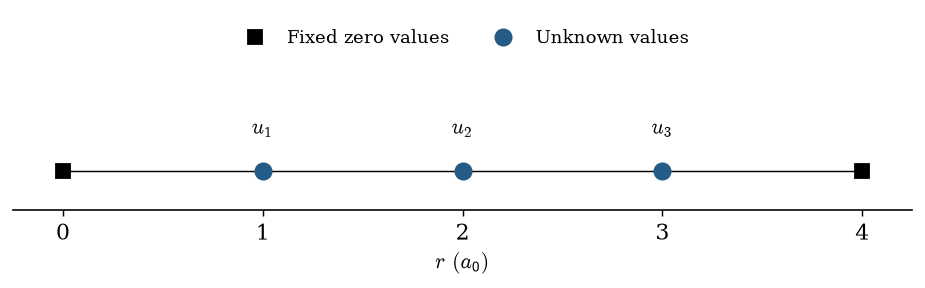

In [11]:
r_small = np.array([1., 2., 3.])
h_small = 1.0
fig, ax = plt.subplots(figsize=(7, 2.1), layout="constrained")
ax.plot([0, 4], [0, 0], color="black", lw=0.8)
ax.plot([0, 4], [0, 0], "s", color="black", ms=8, label="Fixed zero values")
ax.plot(r_small, np.zeros(3), "o", color=BLUE, ms=9, label="Unknown values")
for i, radius in enumerate(r_small, start=1):
    ax.text(radius, 0.14, rf"$u_{i}$", ha="center")
ax.set(xlabel=r"$r\ (a_0)$", yticks=[], xticks=[0, 1, 2, 3, 4],
       xlim=(-0.25, 4.25), ylim=(-0.15, 0.6))
ax.spines["left"].set_visible(False)
ax.legend(frameon=False, loc="upper center", ncol=2, fontsize=10)
plt.show()

### Replace curvature by three neighboring values

$$u''(r_i)\approx\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.$$

$$-\frac{u_{i-1}}{2h^2}+\left(\frac1{h^2}-\frac1{r_i}\right)u_i
-\frac{u_{i+1}}{2h^2}=Eu_i.$$

- One grid point gives one row of the matrix.
- Only the point and its two neighbors are coupled.

$$H\mathbf u=E\mathbf u,\qquad
H=\begin{pmatrix}
h^{-2}-r_1^{-1}&-(2h^2)^{-1}&0\\
-(2h^2)^{-1}&h^{-2}-r_2^{-1}&-(2h^2)^{-1}\\
0&-(2h^2)^{-1}&h^{-2}-r_3^{-1}
\end{pmatrix}.$$

### Build a matrix you can inspect

**Learn**
- `diag(..., k=1)` places values immediately above the diagonal.
- Kinetic energy couples neighbors; potential energy is diagonal.
- **Check:** reproduce the first row by substituting the zero left boundary.

In [14]:
T_small = np.diag(np.ones(3) / h_small**2)
T_small += np.diag(np.full(2, -0.5 / h_small**2), k=1)
T_small += np.diag(np.full(2, -0.5 / h_small**2), k=-1)
V_small = np.diag(-1 / r_small)
H_small = T_small + V_small
print("Hamiltonian (Hartree):\n", H_small)

Hamiltonian (Hartree):
 [[ 0.       -0.5       0.      ]
 [-0.5       0.5      -0.5     ]
 [ 0.       -0.5       0.666667]]


### See which points interact

**Learn**
- Every square is one matrix entry; the printed numbers give its value.
- The three panels share one color scale.
- This coarse matrix explains the construction; it is not an accurate atom.

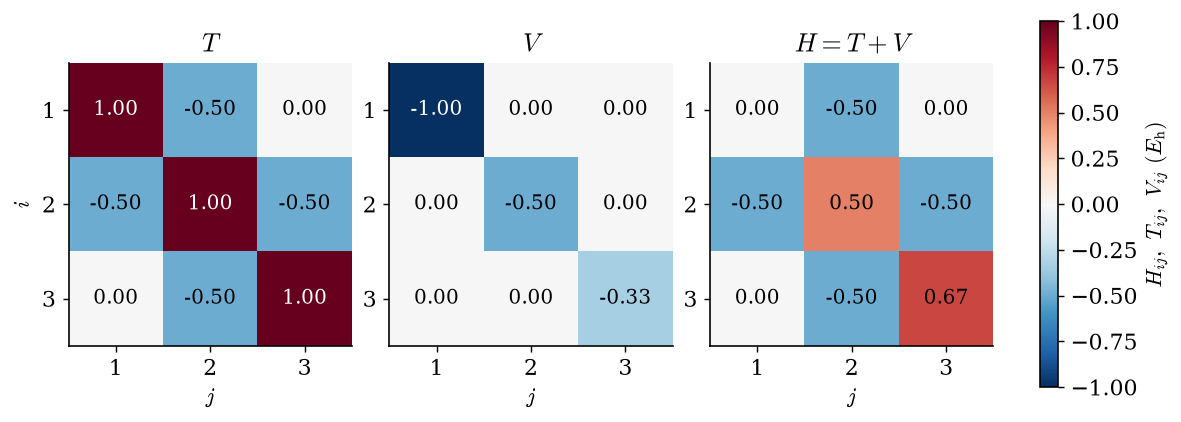

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.4), layout="constrained")
for ax, matrix, name in zip(axes, [T_small, V_small, H_small], ["T", "V", "H=T+V"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                    color="white" if abs(matrix[i, j]) > 0.7 else "black", fontsize=11)
    ax.set(title=rf"${name}$", xticks=[0, 1, 2], yticks=[0, 1, 2],
           xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], xlabel=r"$j$")
axes[0].set_ylabel(r"$i$")
fig.colorbar(im, ax=axes, label=r"$H_{ij},\ T_{ij},\ V_{ij}\ (E_{\mathrm{h}})$", shrink=0.85)
plt.show()

### Make a finer grid

**Learn**
- `M` is the interval count; `r` contains only the interior points.
- The potential depends on the grid, not on an exact wavefunction.

In [16]:
Rmax = 20.0  # Bohr radii.
M = 1000
h = Rmax / M
r = h * np.arange(1, M)
V = -1 / r
print("Grid spacing (bohr):", h)
print("Unknown values:", len(r))

Grid spacing (bohr): 0.02
Unknown values: 999


### Find the lowest energy

**Learn**
- Store the diagonal and one neighboring diagonal instead of a full matrix.
- `select_range=(0, 0)` requests only the lowest eigenvalue and its vector.

$$H_{ii}=h^{-2}+V(r_i),\qquad H_{i,i\pm1}=-\frac1{2h^2}.$$

In [17]:
diagonal = 1 / h**2 + V
off_diagonal = np.full(len(r) - 1, -0.5 / h**2)
energies, vectors = eigh_tridiagonal(
    diagonal, off_diagonal, select="i", select_range=(0, 0))
E_num = energies[0]
v = vectors[:, 0]
print(f"Ground-state energy: {E_num:.8f} Hartree")

Ground-state energy: -0.49995001 Hartree


### Normalize a probability integral

**Learn**
- The solver normalizes a vector sum; the probability integral includes spacing.
- Choose a positive first value for plotting; the overall sign is arbitrary.

$$\sum_i|v_i|^2=1,\qquad u_i=\frac{v_i}{\sqrt h},\qquad h\sum_i|u_i|^2=1.$$

In [18]:
u_num = v / np.sqrt(h)
if u_num[0] < 0:
    u_num = -u_num
P_num = np.abs(u_num)**2
print(f"Vector norm: {np.sum(v**2):.12f}")
print(f"Probability integral: {h * np.sum(P_num):.12f}")

Vector norm: 1.000000000000
Probability integral: 1.000000000000


### Compare functions, not only one number

**Learn**
- The exact solution enters only now, as a reference.
- Lines show the exact functions; open circles show sampled numerical results.
- **Check:** both the shape and the probability peak should agree.

$$u_{1s}(r)=2re^{-r},\qquad P_{1s}(r)=4r^2e^{-2r}.$$

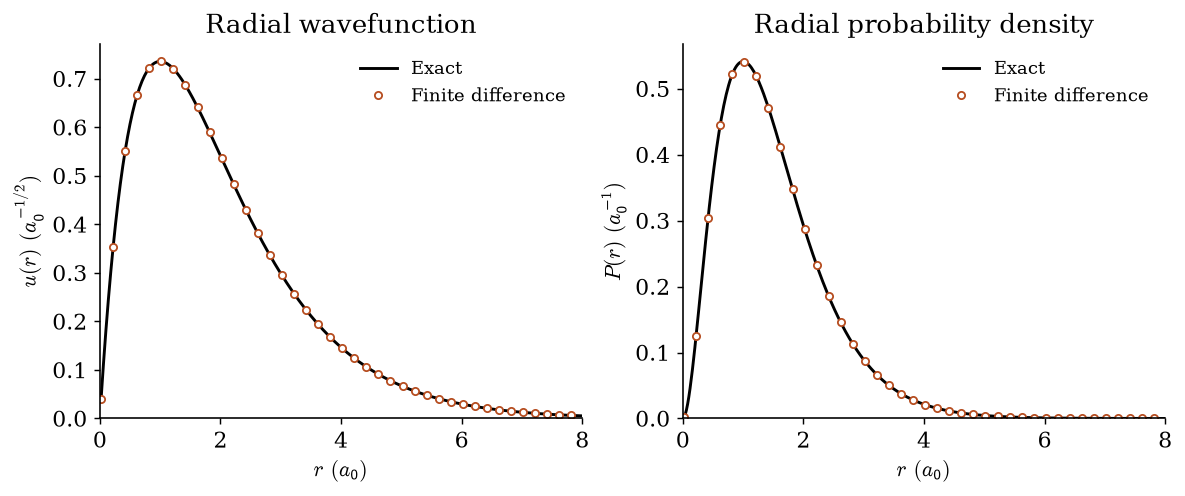

In [19]:
u_reference = 2 * r * np.exp(-r)
P_reference = u_reference**2
visible = r <= 8
sample = np.arange(0, np.count_nonzero(visible), 10)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), sharex=True, layout="constrained")
for ax, exact, computed, ylabel in zip(
        axes, [u_reference, P_reference], [u_num, P_num],
        [r"$u(r)\ (a_0^{-1/2})$", r"$P(r)\ (a_0^{-1})$"]):
    ax.plot(r[visible], exact[visible], color="black", label="Exact")
    ax.plot(r[sample], computed[sample], "o", mfc="white", mec=ORANGE,
            ms=4, label="Finite difference")
    ax.set(xlabel=r"$r\ (a_0)$", ylabel=ylabel, xlim=(0, 8), ylim=(0, None),
           xticks=[0, 2, 4, 6, 8])
    ax.legend(frameon=False, fontsize=10)
axes[0].set_title("Radial wavefunction")
axes[1].set_title("Radial probability density")
plt.show()

### Read the numerical answers

**Learn**
- Energy tests the eigenvalue; mean radius tests the probability distribution.
- The mean radius differs from the radius with the largest probability density.
- A very small matrix residual alone would not prove grid accuracy.

$$\langle r\rangle=\int_0^\infty rP(r)\,dr\approx h\sum_i r_iP_i,\qquad \langle r\rangle_{1s}=\frac32.$$

In [20]:
E_exact = -0.5
mean_radius = h * np.sum(r * P_num)
print("Quantity                  Numerical       Exact")
print(f"Energy (Hartree)         {E_num: .8f}    -0.50000000")
print(f"Mean radius (bohr)       {mean_radius: .8f}     1.50000000")
print(f"Absolute energy error: {abs(E_num - E_exact):.3e} Hartree")

Quantity                  Numerical       Exact
Energy (Hartree)         -0.49995001    -0.50000000
Mean radius (bohr)        1.50010001     1.50000000
Absolute energy error: 4.999e-05 Hartree


## 6. Is the answer converged?

- **Grid test:** keep the outer boundary fixed; decrease the spacing.
- **Boundary test:** keep the spacing fixed; enlarge the outer boundary.
- Changing both at once mixes two errors.

### Reuse the steps we already wrote

**Learn**
- This function repeats the grid, matrix, solve, and normalization steps.
- Its arguments control the two numerical approximations.

In [21]:
def solve_ground_state(rmax, intervals):
    spacing = rmax / intervals
    radii = spacing * np.arange(1, intervals)
    diagonal = 1 / spacing**2 - 1 / radii
    off_diagonal = np.full(len(radii) - 1, -0.5 / spacing**2)
    values, vectors = eigh_tridiagonal(
        diagonal, off_diagonal, select="i", select_range=(0, 0))
    wave = vectors[:, 0] / np.sqrt(spacing)
    if wave[0] < 0:
        wave = -wave
    return radii, values[0], wave

### Halve the spacing

**Learn**
- Double the interval count at a fixed outer boundary.
- **Predict:** does doubling the number of intervals halve the energy error?

In [22]:
grid_counts = np.array([100, 200, 400, 800, 1600])
grid_spacings = 20.0 / grid_counts
grid_errors = []
print("Spacing (bohr)    Energy (Hartree)    Absolute error")
for intervals in grid_counts:
    _, energy, _ = solve_ground_state(20.0, intervals)
    error = abs(energy + 0.5)
    grid_errors.append(error)
    print(f"{20 / intervals:14.4f}    {energy:16.9f}    {error:.3e}")
grid_errors = np.array(grid_errors)
print("Error reduction factors:", grid_errors[:-1] / grid_errors[1:])

Spacing (bohr)    Energy (Hartree)    Absolute error
        0.2000        -0.495097568    4.902e-03
        0.1000        -0.498756211    1.244e-03
        0.0500        -0.499687890    3.121e-04
        0.0250        -0.499921899    7.810e-05
        0.0125        -0.499980470    1.953e-05
Error reduction factors: [3.941531 3.985098 3.996256 3.999063]


### See the error decrease

**Learn**
- Both axes are logarithmic; equal steps show equal ratios.
- The dashed guide represents an error proportional to spacing squared.
- **Check:** halving the spacing reduces this energy error by about four.

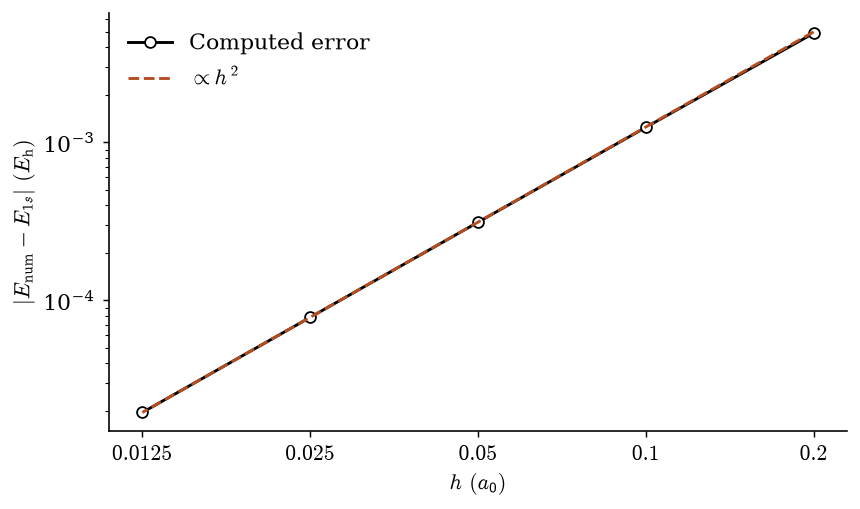

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 3.8), layout="constrained")
ax.loglog(grid_spacings, grid_errors, "o-", color="black", mfc="white", label="Computed error")
ax.loglog(grid_spacings, grid_errors[-1] * (grid_spacings / grid_spacings[-1])**2,
          "--", color=ORANGE, label=r"$\propto h^2$")
ax.set(xlabel=r"$h\ (a_0)$", ylabel=r"$|E_{\mathrm{num}}-E_{1s}|\ (E_{\mathrm{h}})$")
ax.set_xticks(grid_spacings, [rf"${value:g}$" for value in grid_spacings])
ax.set_xticks([], minor=True)
ax.legend(frameon=False)
plt.show()

### Move the outer boundary

**Learn**
- Keep spacing fixed; increase the interval count along with the radius.
- A nearby zero boundary squeezes the wavefunction and changes its energy.
- **Try:** compare the smallest and largest domains.

In [24]:
fixed_spacing = 0.02
outer_radii = [2., 4., 8., 20.]
boundary_results = []
print("Outer radius (bohr)    Energy (Hartree)")
for radius in outer_radii:
    intervals = round(radius / fixed_spacing)
    radii, energy, wave = solve_ground_state(radius, intervals)
    boundary_results.append((radius, radii, energy, wave))
    print(f"{radius:19.1f}    {energy: .9f}")

Outer radius (bohr)    Energy (Hartree)
                2.0    -0.124932628
                4.0    -0.483210363
                8.0    -0.499925090
               20.0    -0.499950010


### See artificial confinement

**Learn**
- Append the imposed zero endpoint values so the boundary is visible.
- All curves use the same axes and probability normalization.
- **Check:** once the boundary is distant, grid error remains.

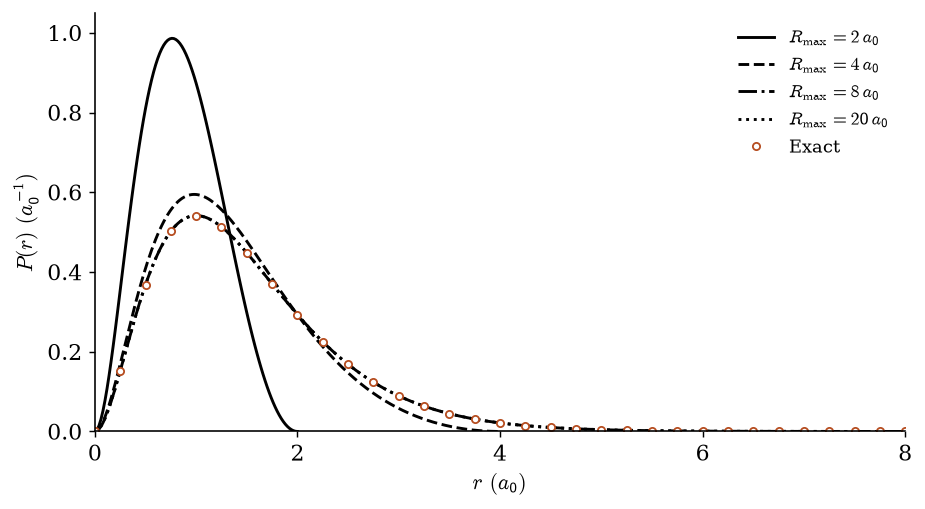

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.8), layout="constrained")
for (radius, radii, energy, wave), style in zip(boundary_results, ["-", "--", "-.", ":"]):
    ax.plot(np.r_[0, radii, radius], np.r_[0, wave**2, 0], style,
            color="black", label=rf"$R_{{\max}}={radius:g}\,a_0$")
ax.plot(r_exact[::25], P_exact[::25], "o", mfc="white", mec=ORANGE, ms=4, label="Exact")
ax.set(xlabel=r"$r\ (a_0)$", ylabel=r"$P(r)\ (a_0^{-1})$", xlim=(0, 8),
       ylim=(0, 1.05), xticks=[0, 2, 4, 6, 8])
ax.legend(frameon=False, fontsize=10)
plt.show()

## 7. Check your understanding

- Flip the sign of a wavefunction. Which plotted quantity stays unchanged?
- Compare the box and oscillator energy ladders. Which gaps are equal?
- Explain why hydrogen density peaks at the nucleus but shell probability does not.
- Point to the code that constructs the kinetic and potential terms.
- Name one parameter change that reduces grid error and one that reduces boundary error.

### References

- Exact solutions: OpenStax, [particle in a box](https://openstax.org/books/university-physics-volume-3/pages/7-4-the-quantum-particle-in-a-box), [harmonic oscillator](https://openstax.org/books/university-physics-volume-3/pages/7-5-the-quantum-harmonic-oscillator), [hydrogen atom](https://openstax.org/books/university-physics-volume-3/pages/8-1-the-hydrogen-atom).
- Eigensolver: [SciPy `eigh_tridiagonal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigh_tridiagonal.html).
- All figures are generated by the code in this notebook.